In [1]:
A = 1103515245
M = 2 ** 32
C = 12345

N = 1000

last_rand = 65535

In [2]:
def next_rand():
    global last_rand
    last_rand = (A * last_rand + C) % M
    return last_rand / M

In [3]:
# Генерируем N чисел с помощью линейно конгруэнтного метода, чтобы получить реализацию выборки N штук с.в. U(0, 1)
data = [next_rand() for _ in range(N)]

In [4]:
import matplotlib.pyplot as plt

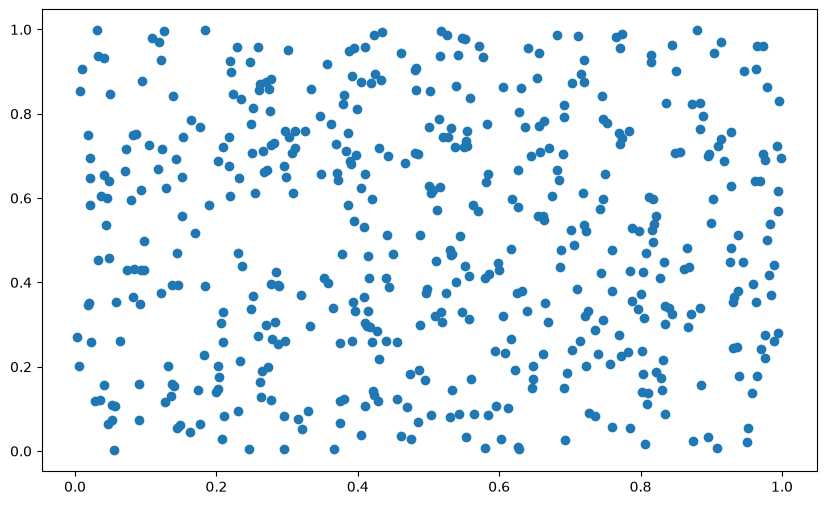

In [5]:
plt.figure(figsize=(10, 6))

# Переходим от 1D случая к 2D, считая первую половину списка координатами на оси абсцисс,
# а вторую часть - координатами на оси ординат
plt.scatter(data[:N//2], data[N//2:])

In [6]:
from random import random

theoretical_data = [random() for _ in range(N)]

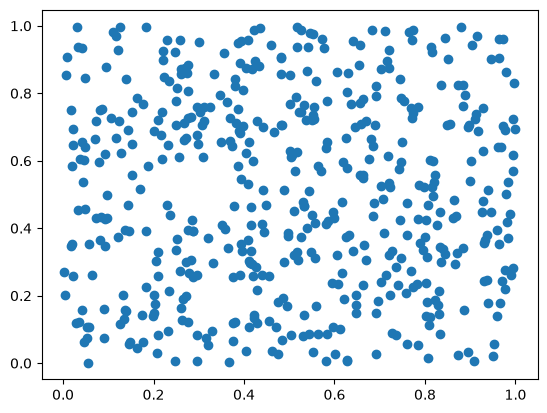

In [7]:
# Отрисуем числа, сгенерированные через built-in функцию random.random
plt.scatter(data[:N//2], data[N//2:])

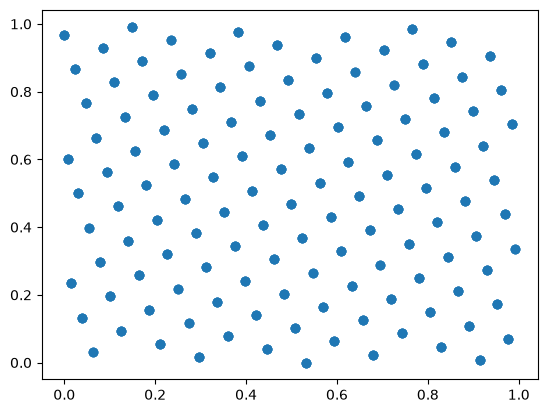

In [8]:
# Пусть не выполняется gcd(c, m) = 1
С = 64

# Ну и возьмем маленькое m, чтобы уменьшить количество различных чисел
M = 128

last_rand = 65535
corrupted_data = [next_rand() for _ in range(N)]

plt.scatter(corrupted_data[:N//2], corrupted_data[N//2:])

In [9]:
from math import e, pi

def gauss_density(x):
    return (1 / (2 * pi) ** 0.5) * (e ** (-x * x / 2))

In [10]:
from time import perf_counter

# Получим гауссовские стандартные с.в. через равномерные с.в.
M = 2 ** 32
C = 12345
N = 10000
last_rand = 65535
data = [next_rand() for _ in range(N)]
gauss = [0] * N

Моделирующие формулы: 0.003442700020968914s


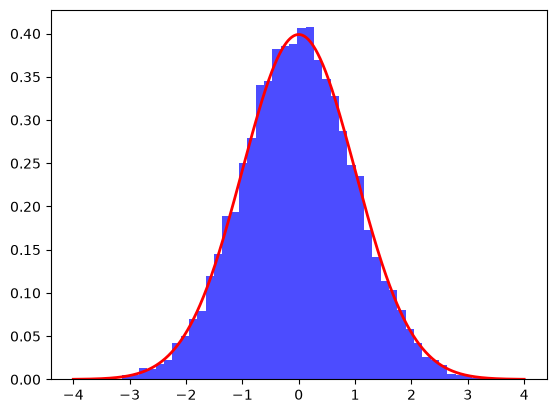

In [11]:
from math import sin, cos, log
import numpy as np

start = perf_counter()

for i in range(0, N, 2):
    r = (-2 * log(data[i])) ** 0.5
    a = 2 * pi * data[i + 1]

    gauss[i] = r * cos(a)
    gauss[i + 1] = r * sin(a)

print(f"Моделирующие формулы: {perf_counter() - start}s")

plt.hist(gauss, bins=50, density=True, alpha=0.7, color='blue', label='Гистограмма (моделирование)')

gauss_x = np.linspace(-4, 4, 1000)
gauss_y = gauss_density(gauss_x)

plt.plot(gauss_x, gauss_y, color='red', linewidth=2)

plt.show()

ЦПТ: 0.006519899994600564s


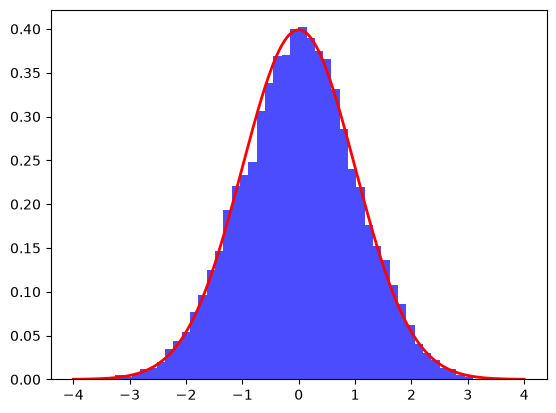

In [12]:
# Теперь используем ЦПТ
n = 12

last_rand = 65535

data = [next_rand() for _ in range(n * 10000)]
gauss_clt = [0] * (len(data) // n)

start = perf_counter()

j = 0
for i in range(0, len(data), n):
    gauss_clt[j] = (sum(data[i:i+n]) - n * 0.5) * ((12.0 / n) ** 0.5)
    j += 1

print(f"ЦПТ: {perf_counter() - start}s")

plt.hist(gauss_clt, bins=50, density=True, alpha=0.7, color='blue', label='Гистограмма (моделирование)')

plt.plot(gauss_x, gauss_y, color='red', linewidth=2)

plt.show()

In [13]:
# Метод обратной функции

from scipy.optimize import newton
import numpy as np

In [14]:
def series(x):
    result = 0.5
    fact = 1
    pow2 = 1

    for k in range(10):
        if k > 0:
            fact *= k
            pow2 *= 2

        term = (-1) ** k * x ** (2 * k + 1) / ((2 * k + 1) * pow2 * fact) / ((2 * np.pi) ** 0.5)
        result += term

    return result

In [15]:
def series_derivative(x):
    fact = 1
    pow2 = 1
    derivative = 0

    for k in range(10):
        if k > 0:
            fact *= k
            pow2 *= 2

        term = (-1) ** k * (2 * k + 1) * x ** (2 * k) / ((2 * k + 1) * pow2 * fact) / ((2 * np.pi) ** 0.5)
        derivative += term

    return derivative

In [16]:
def solve_with_check(u):
    try:
        return newton(lambda x: series(x) - u, 0.0, fprime=series_derivative, tol=1e-3, maxiter=15)
    except:
        return np.nan

Метод обратной функции + метод Ньютона: 1.0954347999650054s


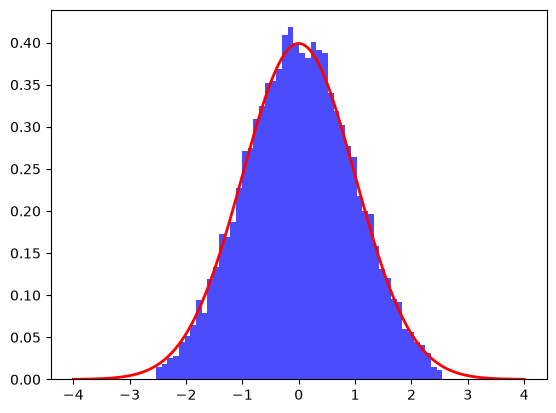

In [17]:
start = perf_counter()

gauss_inv_fn = np.array([solve_with_check(u) for u in data[:len(data)//n]])
gauss_inv_fn = gauss_inv_fn[~np.isnan(gauss_inv_fn)]

print(f"Метод обратной функции + метод Ньютона: {perf_counter() - start}s")

plt.hist(gauss_inv_fn, bins=50, density=True, alpha=0.7, color='blue', label='Гистограмма (моделирование)')

plt.plot(gauss_x, gauss_y, color='red', linewidth=2)
plt.show()